In [ ]:
# Anchor the notebook to the repository root.
#
# Every path below (`data/`, `embeddings/`, the `.pth` weights and the
# `image_path` column stored in the CSVs) is relative to the repository root,
# not to this file. Walking up to the directory that holds `pyproject.toml`
# lets the notebook run from anywhere: `jupyter lab` at the root, from
# `notebooks/`, or from an IDE with its own working directory.
import os
from pathlib import Path

PROJECT_ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").is_file()
)
os.chdir(PROJECT_ROOT)
print(f"Working directory: {PROJECT_ROOT}")

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from PIL import Image

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import adjusted_rand_score, silhouette_score

from pathlib import Path
from sklearn.model_selection import train_test_split

In [2]:
EMBEDDINGS_DIR = Path("embeddings")

resnetdf = pd.read_csv(EMBEDDINGS_DIR / "resnet50_embeddings.csv")
efnetdf  = pd.read_csv(EMBEDDINGS_DIR / "efficientnet_b4_embeddings.csv")

print(f"resnetdf : {resnetdf.shape}")
print(f"efnetdf  : {efnetdf.shape}")

resnetdf : (1506, 2050)
efnetdf  : (1506, 1794)


# Choix du modèle à utiliser pour le clustering

In [3]:
df = efnetdf.copy()

In [4]:
modele = "EfficientNet-B4"

# Separation Train Test


In [5]:
test_df   = df[df["label"].isin([0, 1])] 
train_df = df[df["label"]==-1]
X=train_df.drop(columns=["label", "image_path"])

# Standardisation

In [6]:
scaler = StandardScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.shape

(1406, 1792)

# PCA

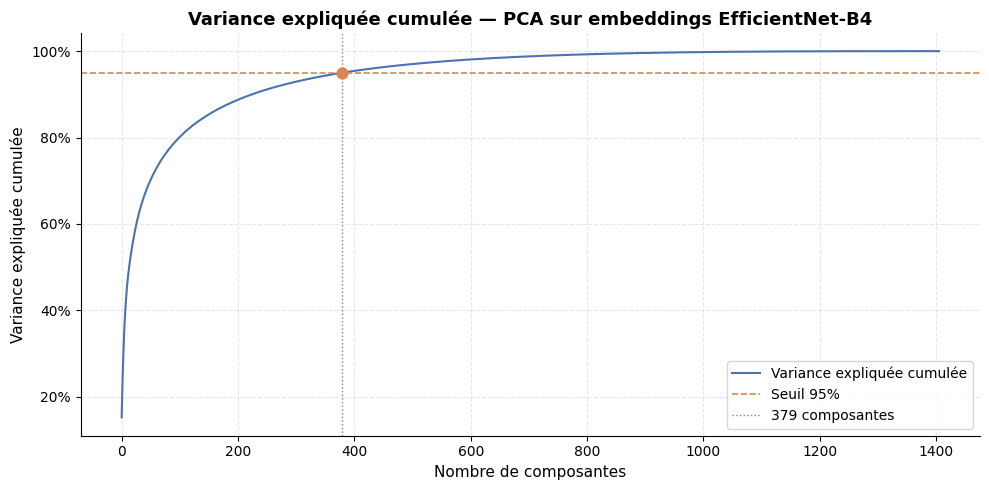

379 dimensions à garder pour conserver 95% de la variance


In [7]:
pcamodel = PCA(n_components=min(X_scaled.shape), random_state=42)
pcamodel.fit(X_scaled)

cumvar = np.cumsum(pcamodel.explained_variance_ratio_)
dim = np.argmax(cumvar > 0.95)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(cumvar, color="#4C72B0", linewidth=1.5, label="Variance expliquée cumulée")
ax.axhline(0.95, color="#DD8452", linewidth=1.2, linestyle="--", label="Seuil 95%")
ax.axvline(dim, color="gray", linewidth=1, linestyle=":", label=f"{dim} composantes")
ax.scatter([dim], [cumvar[dim]], color="#DD8452", zorder=5, s=60)

ax.set_title(f"Variance expliquée cumulée — PCA sur embeddings {modele}", fontsize=13, fontweight="bold")
ax.set_xlabel("Nombre de composantes", fontsize=11)
ax.set_ylabel("Variance expliquée cumulée", fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

print(f"{dim} dimensions à garder pour conserver 95% de la variance")

In [8]:
pcamodel = PCA(n_components=dim)
pcamodel.fit(X_scaled)
X_pca = pcamodel.transform(X_scaled)
X_pca.shape


(1406, 379)

# Clustering

Text(0.5, 0, 'Points triés')

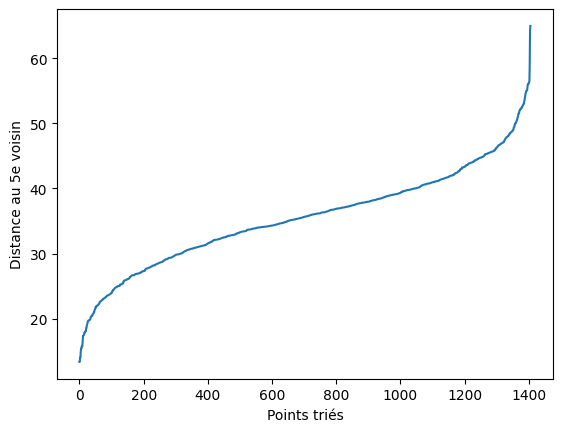

In [9]:
from sklearn.neighbors import NearestNeighbors

k = 5  # = min_samples
nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_pca)
distances, _ = nn.kneighbors(X_pca)

distances = np.sort(distances[:, -1])
plt.plot(distances)
plt.ylabel("Distance au 5e voisin")
plt.xlabel("Points triés")

  p50 : 35.67
  p75 : 40.12
  p85 : 43.22
  p90 : 45.24
  p95 : 48.01
  p99 : 54.67


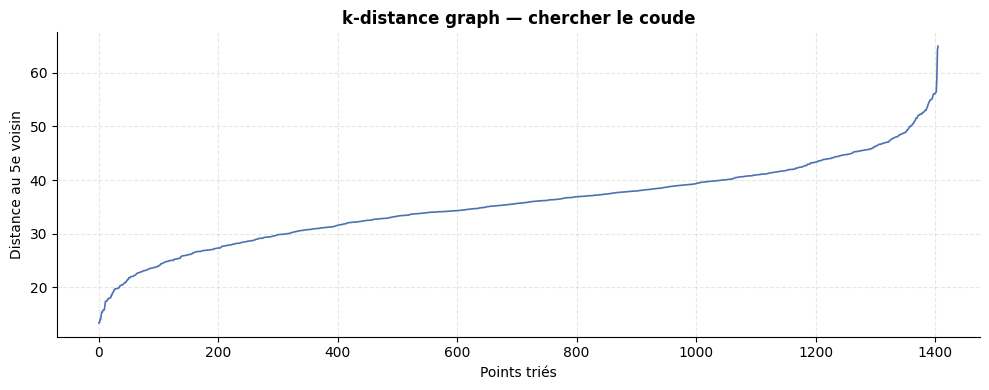

In [19]:
# Distribution des distances au 5e voisin — aide à choisir eps
k = 5
nn2 = NearestNeighbors(n_neighbors=k)
nn2.fit(X_pca)
dists, _ = nn2.kneighbors(X_pca)
d = np.sort(dists[:, -1])

for p in [50, 75, 85, 90, 95, 99]:
    print(f"  p{p:2d} : {np.percentile(d, p):.2f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(d, color="#4C72B0", linewidth=1.2)
ax.set_xlabel("Points triés")
ax.set_ylabel(f"Distance au {k}e voisin")
ax.set_title("k-distance graph — chercher le coude", fontsize=12, fontweight="bold")
ax.grid(True, linestyle="--", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

In [20]:
dbscan= DBSCAN(eps=20, min_samples=5)
dbscan.fit(X_pca)
cluster_labels = dbscan.labels_

In [21]:
# Add cluster labels back to train_df
train_df = train_df.copy()
train_df["cluster"] = cluster_labels

Clusters trouvés : [0, 1, 2, 3]  |  Bruit (label -1) : 1355 points


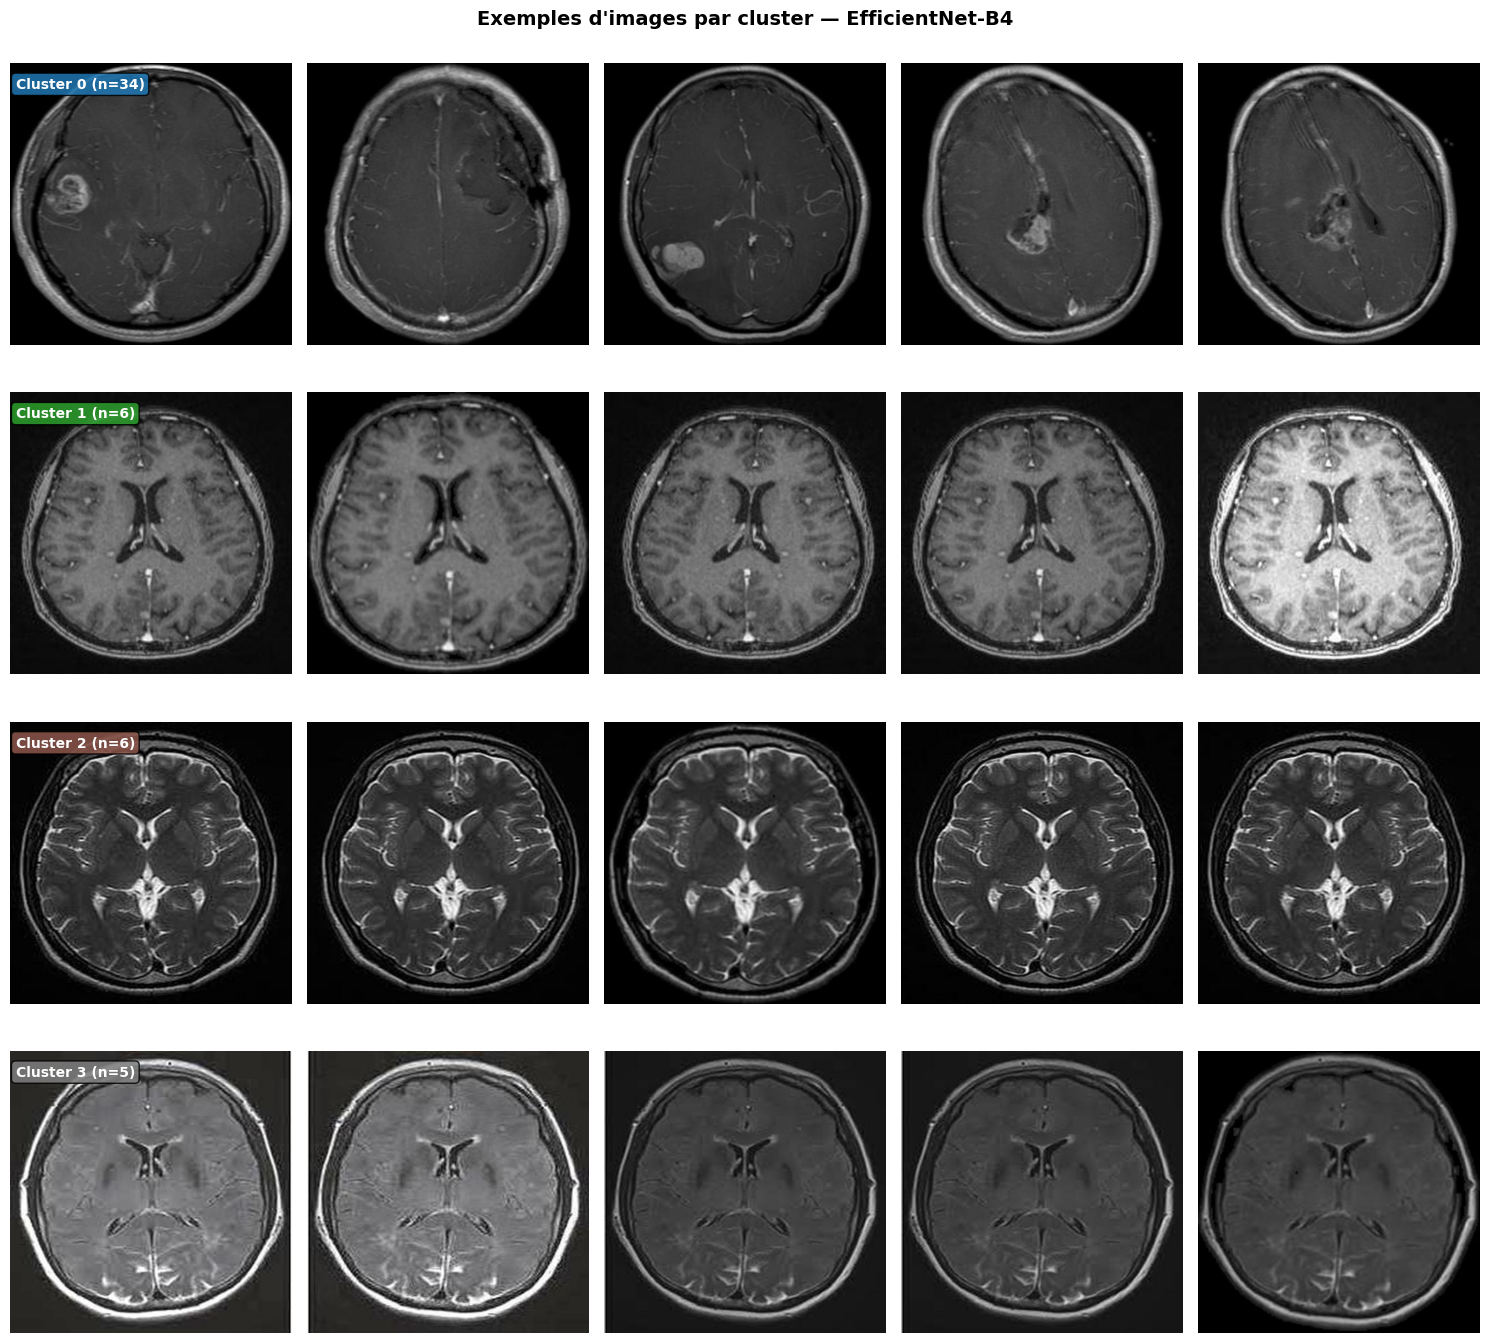

In [23]:
from PIL import Image
import matplotlib.cm as cm

# Actual cluster IDs produced by DBSCAN (exclude noise = -1)
cluster_ids = sorted([int(c) for c in train_df["cluster"].unique() if c != -1])
n_noise = int((train_df["cluster"] == -1).sum())
print(f"Clusters trouvés : {cluster_ids}  |  Bruit (label -1) : {n_noise} points")

# Generate one color per cluster
palette = [cm.tab10(i / max(len(cluster_ids), 1)) for i in range(len(cluster_ids))]
CLUSTER_COLORS = {c: palette[i] for i, c in enumerate(cluster_ids)}

n_samples = 5
fig, axes = plt.subplots(len(cluster_ids), n_samples, figsize=(15, 3.5 * len(cluster_ids)))
fig.suptitle(f"Exemples d'images par cluster — {modele}", fontsize=14, fontweight="bold")

if len(cluster_ids) == 1:
    axes = [axes]

for row_idx, cluster_id in enumerate(cluster_ids):
    subset = train_df[train_df["cluster"] == cluster_id]["image_path"]
    sample_paths = subset.sample(min(n_samples, len(subset)), random_state=42).tolist()

    for col_idx in range(n_samples):
        ax = axes[row_idx][col_idx]
        if col_idx < len(sample_paths):
            with Image.open(sample_paths[col_idx]) as img:
                ax.imshow(img)
        ax.axis("off")

    axes[row_idx][0].text(
        0.02, 0.95, f"Cluster {cluster_id} (n={len(subset)})",
        transform=axes[row_idx][0].transAxes,
        fontsize=10, fontweight="bold", color="white",
        va="top", ha="left",
        bbox=dict(boxstyle="round,pad=0.3", facecolor=CLUSTER_COLORS[cluster_id], alpha=0.85),
    )

plt.tight_layout()
plt.show()

# Visualisation

In [27]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

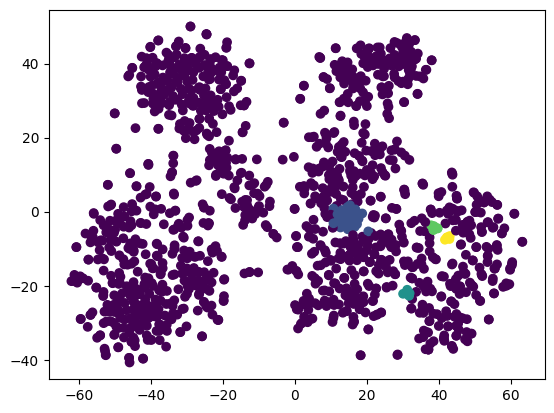

In [28]:
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=cluster_labels)

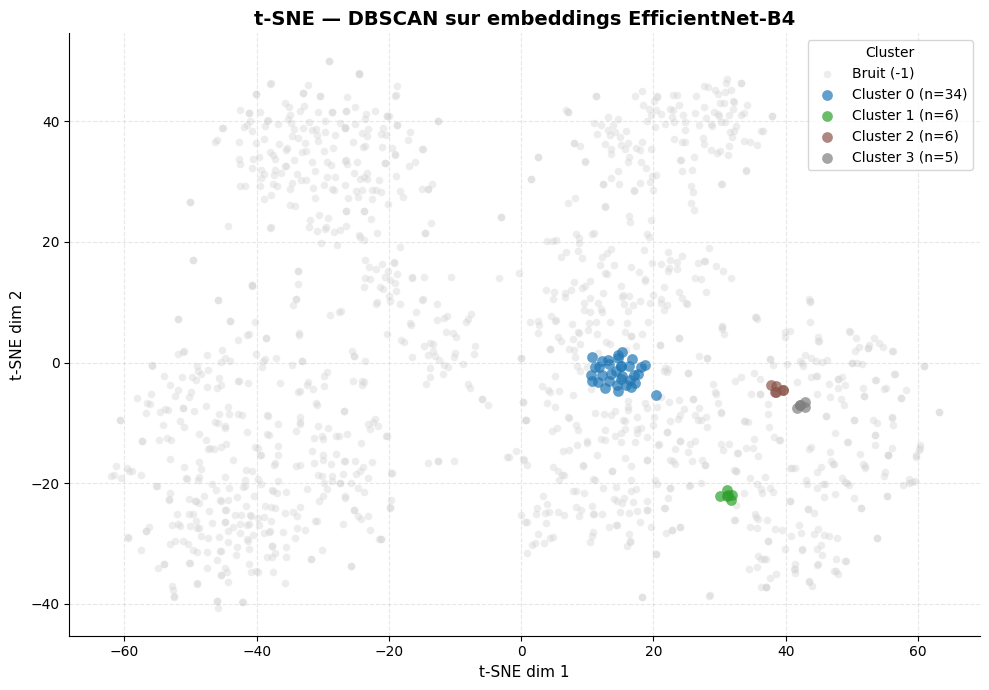

In [29]:
fig, ax = plt.subplots(figsize=(10, 7))

# Noise points in gray
noise_mask = cluster_labels == -1
if noise_mask.any():
    ax.scatter(
        X_tsne[noise_mask, 0], X_tsne[noise_mask, 1],
        c="lightgray", label="Bruit (-1)",
        alpha=0.4, s=30, linewidths=0,
    )

# One color per cluster
for cluster_id in cluster_ids:
    mask = cluster_labels == cluster_id
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=[CLUSTER_COLORS[cluster_id]], label=f"Cluster {cluster_id} (n={mask.sum()})",
        alpha=0.7, s=60, linewidths=0,
    )

ax.set_title(f"t-SNE — DBSCAN sur embeddings {modele}", fontsize=14, fontweight="bold")
ax.set_xlabel("t-SNE dim 1", fontsize=11)
ax.set_ylabel("t-SNE dim 2", fontsize=11)
ax.legend(title="Cluster", fontsize=10, title_fontsize=10)
ax.grid(True, linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

# SCORES

In [30]:
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    classification_report,
)
from sklearn.neighbors import NearestNeighbors

# ── Prédiction sur le test set via 1-NN (DBSCAN n'a pas de predict) ────────
X_test = test_df.drop(columns=["label", "image_path"])
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)
X_test_pca = pcamodel.transform(X_test_scaled)
y_true = test_df["label"].values  # 0=normal, 1=cancer

non_noise_mask = cluster_labels != -1
if non_noise_mask.sum() == 0:
    print("Tous les points sont du bruit — impossible de calculer des métriques.")
else:
    nn_pred = NearestNeighbors(n_neighbors=1)
    nn_pred.fit(X_pca[non_noise_mask])
    _, indices = nn_pred.kneighbors(X_test_pca)
    cluster_pred = cluster_labels[non_noise_mask][indices.flatten()]

    unique_clusters = sorted(set(int(c) for c in cluster_pred))
    n_clusters = len(unique_clusters)

    # ── ARI (toujours calculable) ──────────────────────────────────────────
    ari = adjusted_rand_score(y_true, cluster_pred)
    sil = silhouette_score(X_pca, cluster_labels) if len(set(cluster_labels)) > 1 else float("nan")
    print(f"Clusters présents dans le test set : {unique_clusters}")
    print(f"ARI        : {ari:.4f}")
    print(f"Silhouette : {sil:.4f}\n")

    # ── Distribution par cluster ───────────────────────────────────────────
    print("Distribution cancer/normal par cluster :")
    print(f"  {'Cluster':>8}  {'n':>5}  {'Normal':>7}  {'Cancer':>7}  {'Pureté':>7}")
    print("  " + "-" * 42)
    for c in unique_clusters:
        mask = cluster_pred == c
        n = mask.sum()
        n_cancer = (y_true[mask] == 1).sum()
        n_normal = (y_true[mask] == 0).sum()
        purity = max(n_cancer, n_normal) / n if n > 0 else 0
        print(f"  {c:>8}  {n:>5}  {n_normal:>7}  {n_cancer:>7}  {purity:>6.0%}")

    # ── Métriques binaires (seulement si exactement 2 clusters) ───────────
    if n_clusters == 2:
        c0, c1 = unique_clusters
        binary_pred = (cluster_pred == c1).astype(int)
        acc_direct   = (binary_pred == y_true).mean()
        acc_inverted = (1 - binary_pred == y_true).mean()

        if acc_direct >= acc_inverted:
            aligned_pred = binary_pred
            cluster_to_class = {c0: "normal", c1: "cancer"}
        else:
            aligned_pred = 1 - binary_pred
            cluster_to_class = {c0: "cancer", c1: "normal"}

        print(f"\nMapping retenu : cluster {c0} → {cluster_to_class[c0]}, cluster {c1} → {cluster_to_class[c1]}")
        print("=" * 45)
        print(f"  Accuracy   : {accuracy_score(y_true, aligned_pred):.4f}")
        print(f"  Precision  : {precision_score(y_true, aligned_pred):.4f}  (cancer=positif)")
        print(f"  Recall     : {recall_score(y_true, aligned_pred):.4f}  (cancer=positif)")
        print(f"  F1-score   : {f1_score(y_true, aligned_pred):.4f}")
        print(f"  F2-score   : {fbeta_score(y_true, aligned_pred, beta=2):.4f}  (recall x2)")
        print("=" * 45)
        print()
        print(classification_report(y_true, aligned_pred, target_names=["Normal", "Cancer"]))

        cm = confusion_matrix(y_true, aligned_pred)
        fig, ax = plt.subplots(figsize=(5, 4))
        ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal (0)", "Cancer (1)"]).plot(
            ax=ax, colorbar=False, cmap="Blues"
        )
        ax.set_title("Matrice de confusion — DBSCAN vs labels réels", fontsize=12, fontweight="bold")
        plt.tight_layout()
        plt.show()
    else:
        print(f"\n⚠ {n_clusters} clusters → métriques binaires (accuracy, F1…) non applicables.")
        print("  Ajuste eps/min_samples pour obtenir exactement 2 clusters,")
        print("  ou considère une fusion manuelle des clusters.")

Clusters présents dans le test set : [0, 1, 2, 3]
ARI        : 0.0471
Silhouette : -0.1074

Distribution cancer/normal par cluster :
   Cluster      n   Normal   Cancer   Pureté
  ------------------------------------------
         0     19        7       12     63%
         1     45       18       27     60%
         2     24       19        5     79%
         3     12        6        6     50%

⚠ 4 clusters → métriques binaires (accuracy, F1…) non applicables.
  Ajuste eps/min_samples pour obtenir exactement 2 clusters,
  ou considère une fusion manuelle des clusters.
